<a href="https://colab.research.google.com/github/hania-sajjad/WEEK-1-TASK/blob/main/EDA_Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Display all columns (do not hide)
pd.set_option('display.max_columns', None)

In [2]:
#UPLOAD DATASET
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#LOAD DATASET
file_path = "/content/drive/MyDrive/Week1Data/online_retail_II.xlsx"
df = pd.read_excel(file_path)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
#BASIC INFORMATION
#Shape
print("Shape of the dataset:", df.shape)
#Column Names
print("\nColumn Names:")
print(df.columns)
#Data Type of each Column
print("\nData Types:")
print(df.dtypes)

Shape of the dataset: (525461, 8)

Column Names:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [5]:
#DATASET INFORMATION
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [6]:
#STATISTICAL SUMMARY
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [7]:
#MISSING VALUE ANALYSIS
#Missing Values in each Column
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)
#Missing Value Percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("Percentage of Missing Values:")
print(missing_percentage)

Missing Values in Each Column:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64
Percentage of Missing Values:
Invoice         0.000000
StockCode       0.000000
Description     0.557225
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    20.539488
Country         0.000000
dtype: float64


In [8]:
#DUPLICATE ROWS ANALYSIS
duplicate_rows = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicate_rows)

Number of Duplicate Rows: 6865


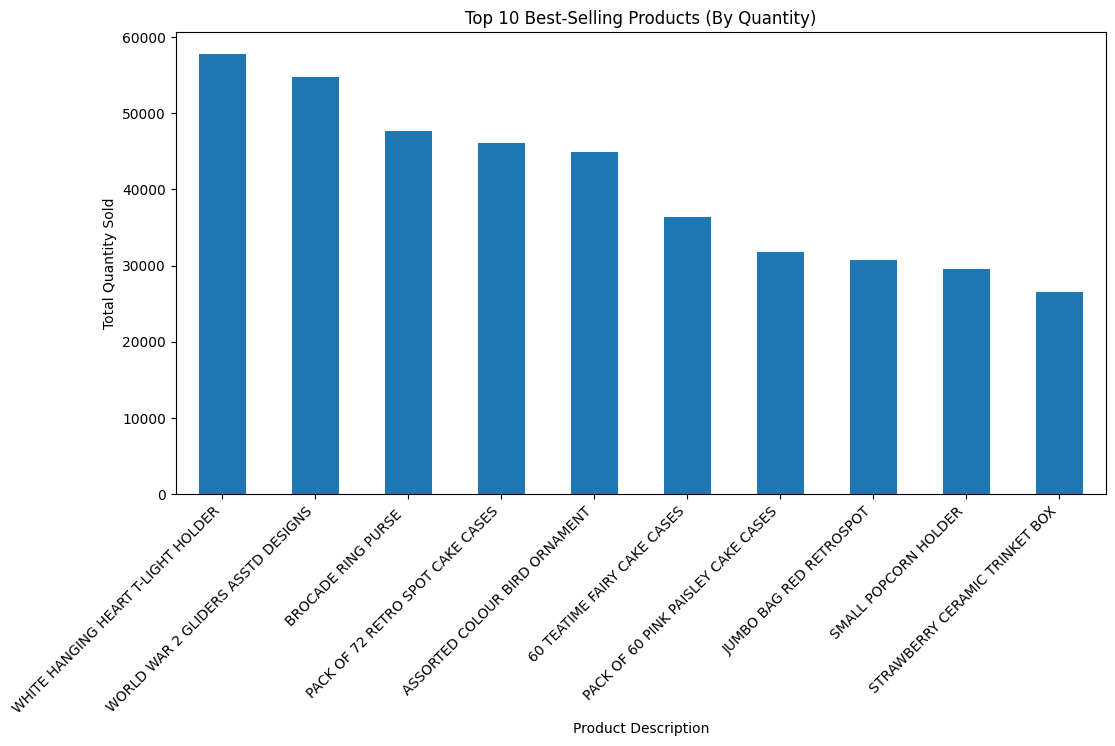

In [9]:
#TOP 10 PRODUCTS BY QUANTITY
top_products_qty = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products_qty

#Plot
plt.figure(figsize=(12,6))

top_products_qty.plot(kind="bar")

plt.title("Top 10 Best-Selling Products (By Quantity)")
plt.xlabel("Product Description")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha='right')

plt.show()

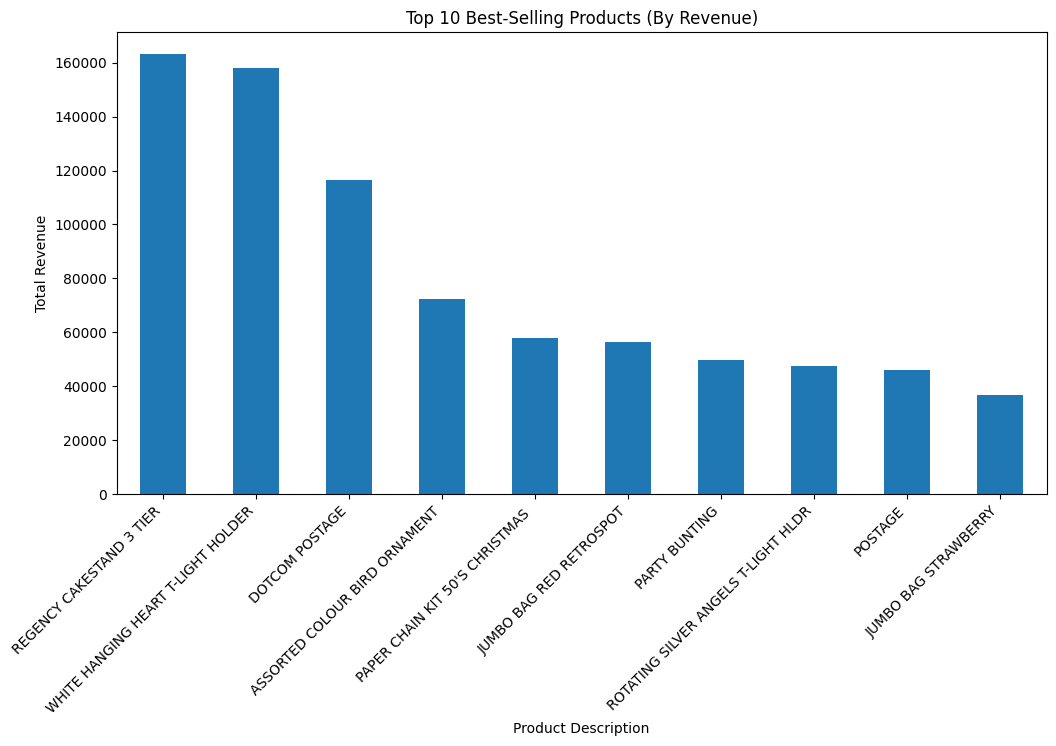

In [10]:
#TOP 10 PRODUCTS BY REVENUE
df["Revenue"] = df["Quantity"] * df["Price"]  #Create Column
top_products_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_products_revenue

#Plot
plt.figure(figsize=(12,6))

top_products_revenue.plot(kind="bar")

plt.title("Top 10 Best-Selling Products (By Revenue)")
plt.xlabel("Product Description")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha='right')

plt.show()

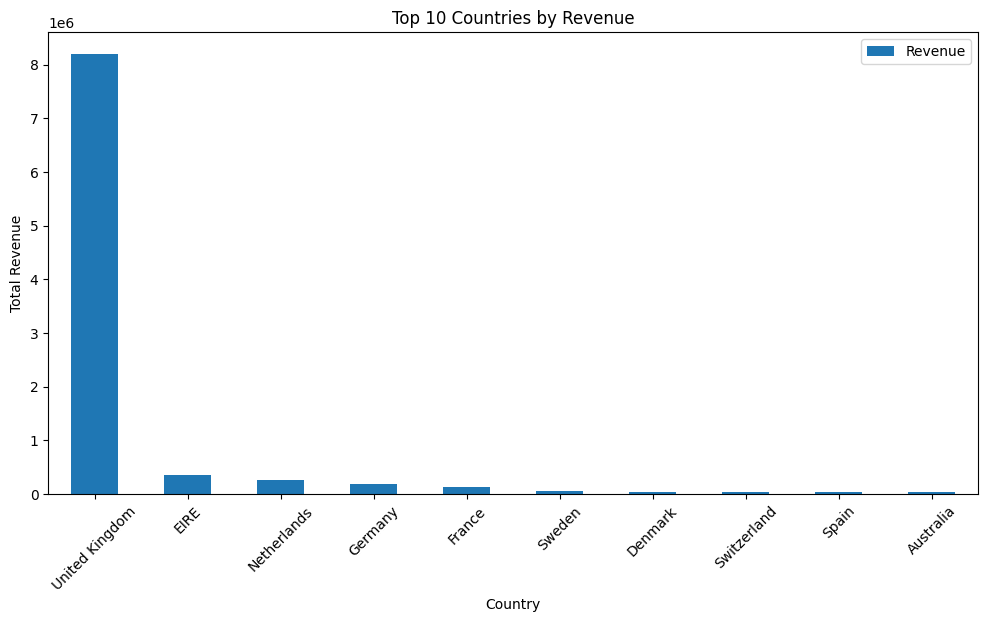

In [11]:
#SALES PERFORMANCE BY COUNTRY
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_sales.head(10)

#Plot TOP 10 Countries
plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.legend(["Revenue"])

plt.show()

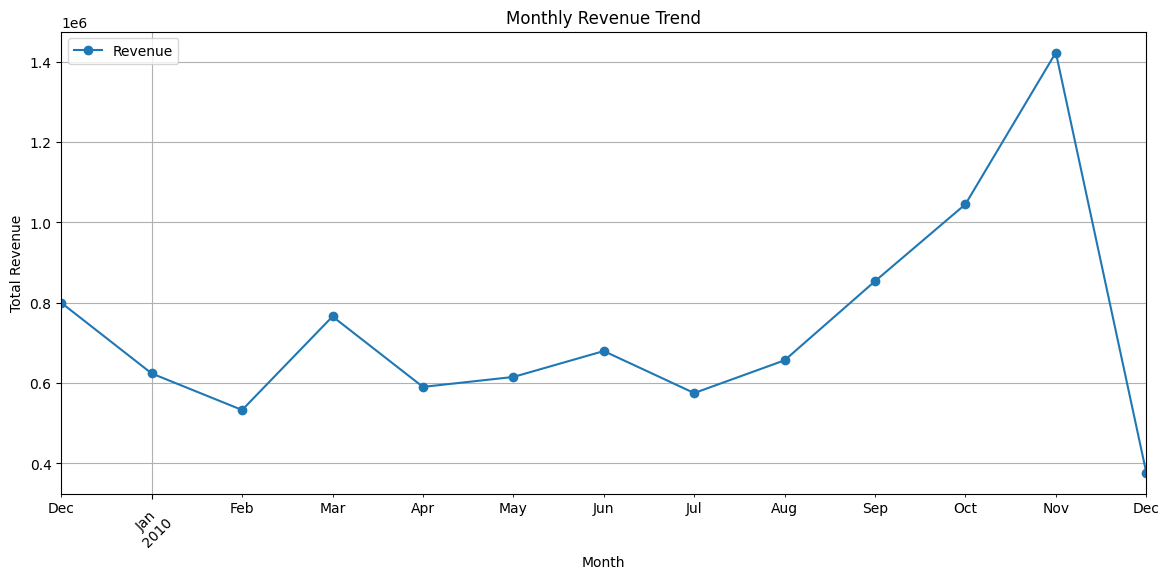

In [12]:
#PLOT REVENUE OVER TIME PERIOD
#Convert InvoiceDate to DateTime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
#Create Month-Year Column
df["Month"] = df["InvoiceDate"].dt.to_period("M")
#Monthly Revenue
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
)
monthly_revenue
#Plot
plt.figure(figsize=(14,6))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.legend(["Revenue"])
plt.grid(True)
plt.show()

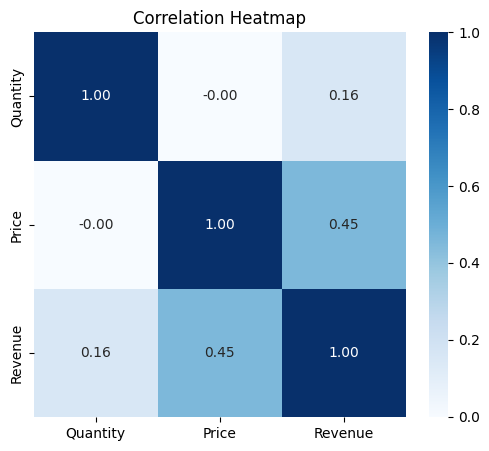

In [13]:
#CORRELATION HEAT MAP
#Select only numerical columns
correlation = df[["Quantity", "Price", "Revenue"]].corr()

#Plot the heatmap
plt.figure(figsize=(6,5))

sns.heatmap(correlation,
            annot=True,
            cmap="Blues",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

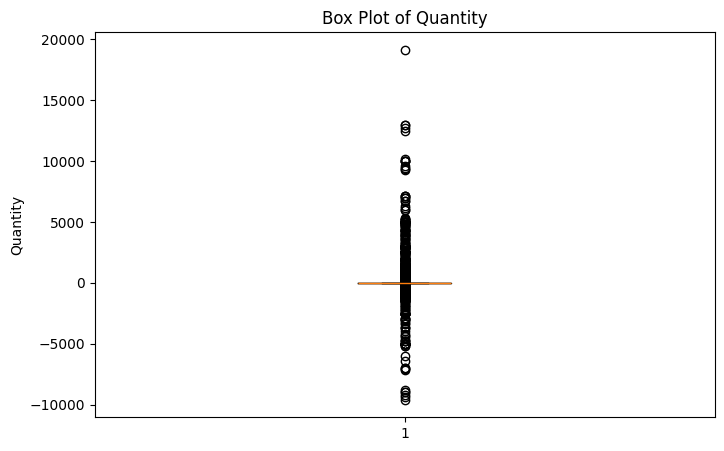

In [14]:
#BOXPLOT FOR QUANTITY
plt.figure(figsize=(8,5))

plt.boxplot(df["Quantity"].dropna())

plt.title("Box Plot of Quantity")
plt.ylabel("Quantity")
plt.show()

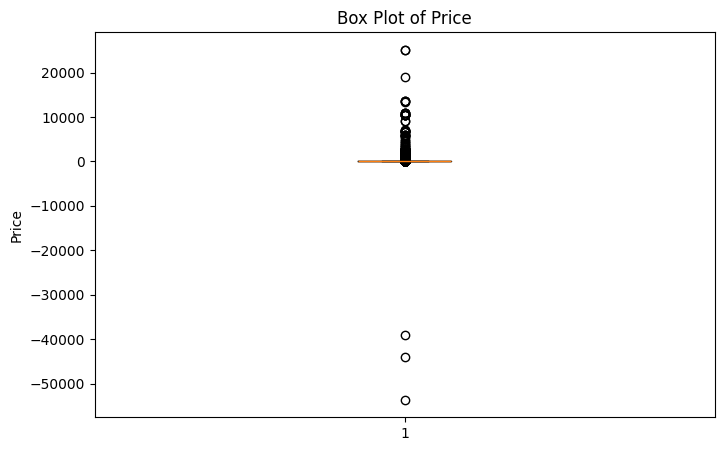

In [15]:
#BOXPLOT FOR PRICE
plt.figure(figsize=(8,5))

plt.boxplot(df["Price"].dropna())

plt.title("Box Plot of Price")
plt.ylabel("Price")
plt.show()

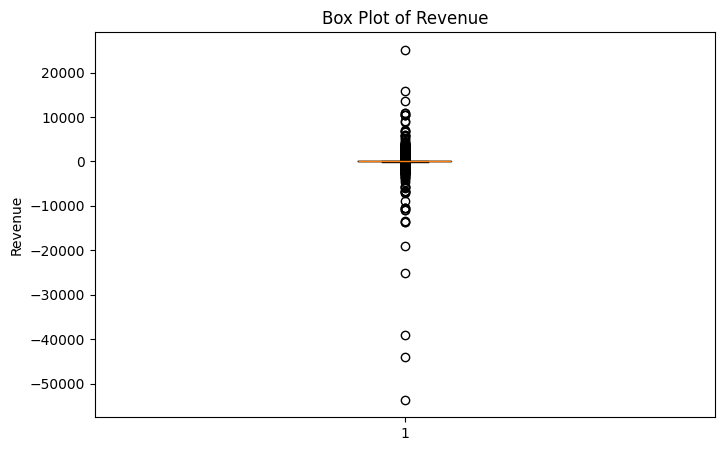

In [16]:
#BOXPLOT FOR REVENUE
plt.figure(figsize=(8,5))

plt.boxplot(df["Revenue"].dropna())

plt.title("Box Plot of Revenue")
plt.ylabel("Revenue")
plt.show()

**Business Insights**

1. Around 20.54% of the Customer ID values are missing. This makes it difficult to identify individual customers and analyze their purchasing behavior.

2. The dataset contains 6,865 duplicate rows. These duplicates should be checked and handled during data preprocessing before building a machine learning model.

3. The United Kingdom generates the highest revenue, making it the retailer's largest and most important market.

4. November has the highest monthly revenue, showing that sales increase during the holiday shopping season.

5. The products with the highest quantity sold are not always the products with the highest revenue. This shows that product price also plays an important role in generating revenue.

6. The correlation heatmap shows a moderate positive relationship between Price and Revenue (0.45), while Quantity has only a weak positive relationship with Revenue (0.16).

7. The box plots show several extreme outliers in Quantity, Price, and Revenue. These may represent bulk purchases, product returns, or high-value transactions. No data was removed during this analysis.